# Phase 4: A Brain-Controlled Sorting Arm

So far we have a decoder that guesses left or right ten times a second, and a Kalman filter that turns those guesses into a steady intent signal in $[-1, +1]$. Now we use that signal to control a **simulated robotic arm** on a real task.

![Closing the loop](../images/arm_control_loop.png)

**The task.** Objects arrive one at a time. The person must sort each one into the **left bin** or the **right bin** using only imagined movement, just as in the dataset: on each cue they imagine a left-fist or a right-fist movement. The arm starts at the center and carries the object toward the bin the person is "pointing" at. Reaching a bin is a selection. We score it correct if it's the bin the person meant, wrong if it's the other one, and "no selection" if time runs out first.

**The arm.** A 3-joint arm: a base that rotates, a shoulder and an elbow. We command where the hand should be, and *inverse kinematics* works out the joint angles.

**The control rule.** The intent $\hat{x}$ is a continuous number, so we treat it like a joystick. The hand moves along the line between the bins at a speed set by the intent:

$$\dot{h} = g \cdot \mathrm{dz}(\hat{x}), \qquad \mathrm{dz}(u) = \begin{cases} 0 & |u| < d \\ \operatorname{sign}(u)\,\dfrac{|u| - d}{1 - d} & |u| \ge d \end{cases}$$

- $g$ is the maximum hand speed.
- The **deadzone** $d$ makes the arm hold still when the intent is near zero (the system is unsure), which is the safe default for a real device.

**How we'll judge it.**

| Metric | Meaning |
|---|---|
| Correct / wrong / no selection | Where did each object end up? |
| Time per selection | Seconds from the cue until the hand reaches a bin |
| Information transfer rate (ITR) | Bits per minute conveyed by the person to the machine. For 2 choices with accuracy $P$: $B = 1 + P\log_2 P + (1-P)\log_2(1-P)$ bits per selection |

We compare two identical arms fed the same brain data, one driven by the **raw decoder** and one by the **Kalman-filtered intent**, then repeat the experiment on several subjects.

**Honest scope:** this is a simulation. We replay recorded EEG through the decoder as if it were live. There is no physical robot and no real-time acquisition. Our ITR also ignores the rest periods between trials, so it's an upper bound.

**Plan:**

1. Rebuild the decoder + Kalman stream for subject 7
2. Build the 3D arm: forward and inverse kinematics
3. Simulate the sorting task
4. Compare raw vs. Kalman control
5. Benchmark across subjects
6. Animate it

In [1]:
import numpy as np                                   # arrays and math
import matplotlib.pyplot as plt                      # plotting and animation
import mne                                           # EEG loading and processing
from mne.datasets import eegbci                      # PhysioNet dataset loader
from mne.io import concatenate_raws, read_raw_edf    # reading and combining recordings
from mne.decoding import CSP                         # Common Spatial Patterns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold

np.random.seed(42)
mne.set_log_level("WARNING")
print(f"MNE version: {mne.__version__}")

MNE version: 1.13.2


In [2]:
def load_subject(subject, tmin=0.5, tmax=4.0):
    """Load, filter and epoch one subject's left/right imagery trials."""
    paths = eegbci.load_data(subject, [4, 8, 12])
    raw = concatenate_raws([read_raw_edf(p, preload=True) for p in paths])
    eegbci.standardize(raw)
    raw.filter(l_freq=8.0, h_freq=30.0, verbose=False)
    events, _ = mne.events_from_annotations(raw, event_id={"T1": 2, "T2": 3}, verbose=False)
    ep = mne.Epochs(raw, events, event_id={"left": 2, "right": 3}, tmin=-1.0, tmax=4.0,
                    baseline=None, picks="eeg", preload=True, verbose=False)
    ep.crop(tmin=tmin, tmax=tmax)
    return ep.get_data(), ep.events[:, 2], ep.info["sfreq"]

def decode_stream(subject):
    """Sliding-window, out-of-sample P(right) for every trial of one subject."""
    Xs, ys, sf = load_subject(subject)
    wl, st = int(1.5 * sf), int(0.1 * sf)
    Xw_ = np.stack([Xs[:, :, s:s + wl] for s in range(0, Xs.shape[2] - wl + 1, st)], axis=1)
    nt, nw = Xw_.shape[:2]
    p = np.zeros((nt, nw))
    model = Pipeline([("csp", CSP(n_components=4, reg=None, log=True)),
                      ("lda", LinearDiscriminantAnalysis())])
    for tr, te in StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(Xs, ys):
        model.fit(Xw_[tr].reshape(-1, *Xw_.shape[2:]), np.repeat(ys[tr], nw))
        p[te] = model.predict_proba(Xw_[te].reshape(-1, *Xw_.shape[2:]))[:, 1].reshape(len(te), nw)
    return p, (ys == 3)

def kalman_filter(z, Q, R, x0=0.0, P0=1.0):
    """1-D Kalman filter: state = intent in [-1, +1], random-walk process model."""
    x, P = x0, P0
    est = np.zeros(len(z))
    for t, zt in enumerate(z):
        P_pred = P + Q
        K = P_pred / (P_pred + R)
        x = x + K * (zt - x)
        P = (1 - K) * P_pred
        est[t] = x
    return est

subject = 7
dt = 0.1
p, is_r = decode_stream(subject)
z_raw = (2 * p - 1).reshape(-1)                              # raw decoder reading in [-1, +1]
truth = np.repeat(np.where(is_r, 1, -1), p.shape[1])         # true intent (for scoring only)
R = np.var(z_raw - truth)
z_kf = kalman_filter(z_raw, Q=0.1, R=R)                      # smoothed intent

print(f"Subject {subject}: {len(z_raw)} steps = {len(z_raw) * dt:.1f} s of control")
print(f"Raw accuracy:    {np.mean((z_raw > 0) == (truth > 0)):.3f}")
print(f"Kalman accuracy: {np.mean((z_kf > 0) == (truth > 0)):.3f}")

/Users/victordeni/brain-controlled-robotic-arm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Subject 7: 945 steps = 94.5 s of control
Raw accuracy:    0.957
Kalman accuracy: 0.957


## Step 2: Building the 3D Arm

The arm has three joints: a **base** that rotates left and right, a **shoulder**, and an **elbow**. Our controller only decides *where the hand should be*. **Inverse kinematics (IK)** turns that position into joint angles. **Forward kinematics (FK)** does the reverse, and we use it to draw the arm and to check the IK.

![Inverse kinematics geometry](../images/ik_geometry.png)

**The setup.** The hand slides along a straight line in front of the arm, at a fixed depth ($y = 1$) and height ($z = 0.45$). The left bin is at $x = -1$ and the right bin at $x = +1$. Both links are length 1, and the shoulder sits 0.7 above the table.

**Inverse kinematics, in three steps:**

1. **Rotate the base** to face the target: $\varphi = \operatorname{atan2}(x,\, y)$. After that, the problem is flat, because the arm lives in one vertical plane.
2. **Find the elbow bend** with the law of cosines. With $r = \sqrt{x^2+y^2}$ the horizontal distance and $\Delta z$ the height difference between hand and shoulder, the straight-line shoulder-to-hand distance is $D = \sqrt{r^2 + \Delta z^2}$ and:

$$\cos\theta_2 = \frac{D^2 - L_1^2 - L_2^2}{2\,L_1 L_2}$$

   Two mirror-image solutions exist (elbow up or down). We choose elbow up, so $\theta_2 < 0$.
3. **Find the shoulder angle**: aim at the target, then correct for the elbow bend:

$$\theta_1 = \operatorname{atan2}(\Delta z,\, r) + \operatorname{atan2}\big(L_2 \sin|\theta_2|,\; L_1 + L_2\cos\theta_2\big)$$

**How we check it:** feed a target into IK, feed the resulting angles into FK, and confirm the hand lands exactly on the target. If both are right, this round trip returns the starting point.

In [3]:
# ---- arm geometry (arbitrary length units) ----
L1, L2 = 1.0, 1.0          # upper-arm and forearm lengths
H0 = 0.7                   # shoulder height above the table
Y0, Z0 = 1.0, 0.45         # the hand slides along the line y = Y0, at height z = Z0
BIN_X = 1.0                # bins sit at x = -BIN_X (left) and x = +BIN_X (right)

def inverse_kinematics(hx, hy=Y0, hz=Z0):
    """Hand position (x, y, z) -> joint angles (base yaw, shoulder, elbow)."""
    yaw = np.arctan2(hx, hy)                      # rotate the base toward the target
    r = np.hypot(hx, hy)                          # horizontal distance from the base
    dz = hz - H0                                  # height difference from the shoulder
    D = np.hypot(r, dz)                           # straight-line shoulder-to-hand distance
    c = (D**2 - L1**2 - L2**2) / (2 * L1 * L2)    # law of cosines
    elbow = -np.arccos(np.clip(c, -1, 1))         # negative = elbow bends upward
    shoulder = np.arctan2(dz, r) + np.arctan2(L2 * np.sin(-elbow), L1 + L2 * np.cos(elbow))
    return yaw, shoulder, elbow

def forward_kinematics(yaw, shoulder, elbow):
    """Joint angles -> 3D positions of base, shoulder, elbow and hand."""
    def to3d(r, z):
        return np.array([r * np.sin(yaw), r * np.cos(yaw), z])
    base = np.array([0.0, 0.0, 0.0])
    shoulder_pt = np.array([0.0, 0.0, H0])
    elbow_pt = to3d(L1 * np.cos(shoulder), H0 + L1 * np.sin(shoulder))
    hand_pt = to3d(L1 * np.cos(shoulder) + L2 * np.cos(shoulder + elbow),
                   H0 + L1 * np.sin(shoulder) + L2 * np.sin(shoulder + elbow))
    return base, shoulder_pt, elbow_pt, hand_pt

# Check: IK then FK must land back on the target
for hx in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    hand = forward_kinematics(*inverse_kinematics(hx))[3]
    assert np.allclose(hand, [hx, Y0, Z0], atol=1e-9), (hx, hand)
print("IK/FK round-trip check passed for 5 targets")

for hx in [-1.0, 0.0, 1.0]:
    yaw, sh, el = inverse_kinematics(hx)
    print(f"hand x = {hx:+.1f}:  base {np.degrees(yaw):+6.1f}°   shoulder {np.degrees(sh):+6.1f}°   elbow {np.degrees(el):+6.1f}°")

IK/FK round-trip check passed for 5 targets
hand x = -1.0:  base  -45.0°   shoulder  +34.1°   elbow  -88.2°
hand x = +0.0:  base   +0.0°   shoulder  +44.9°   elbow -118.0°
hand x = +1.0:  base  +45.0°   shoulder  +34.1°   elbow  -88.2°


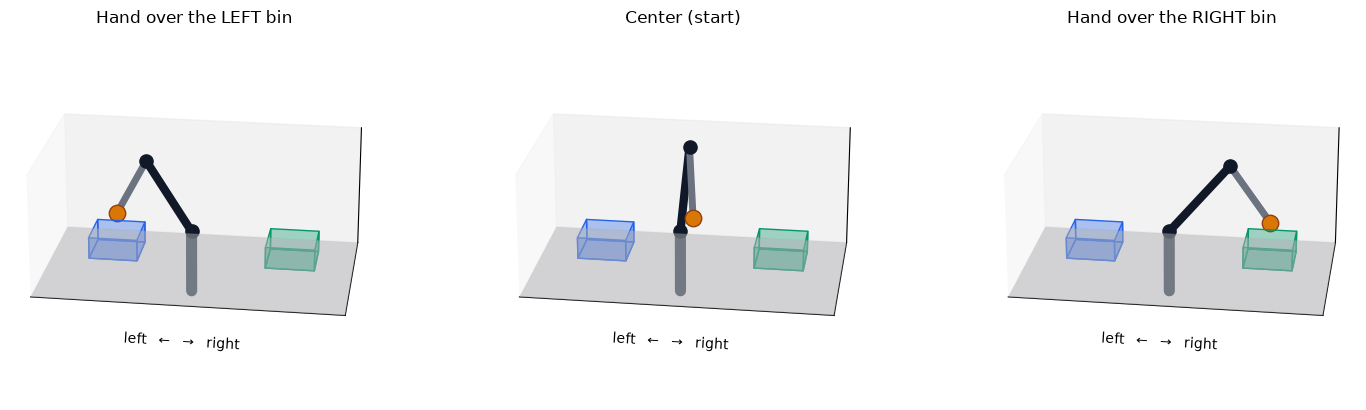

In [4]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

LEFT_C, RIGHT_C = "#2563eb", "#059669"      # same colors as the rest of the project

def box(ax, cx, cy, w, d, h, color, alpha=0.35):
    """Draw an open-top box (a bin) centered at (cx, cy) on the table."""
    x0, x1, y0, y1 = cx - w/2, cx + w/2, cy - d/2, cy + d/2
    faces = [[(x0,y0,0),(x1,y0,0),(x1,y1,0),(x0,y1,0)],
             [(x0,y0,0),(x1,y0,0),(x1,y0,h),(x0,y0,h)],
             [(x0,y1,0),(x1,y1,0),(x1,y1,h),(x0,y1,h)],
             [(x0,y0,0),(x0,y1,0),(x0,y1,h),(x0,y0,h)],
             [(x1,y0,0),(x1,y1,0),(x1,y1,h),(x1,y0,h)]]
    ax.add_collection3d(Poly3DCollection(faces, facecolors=color, edgecolors=color, alpha=alpha))

def setup_scene(ax):
    ax.set_xlim(-1.7, 1.7); ax.set_ylim(-0.4, 1.6); ax.set_zlim(0, 1.4)
    ax.set_box_aspect((3.4, 2.0, 1.4))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])       # clean look: no tick clutter
    ax.set_xlabel("left   ←   →   right")
    ax.view_init(elev=22, azim=-82)
    xx, yy = np.meshgrid([-1.7, 1.7], [-0.4, 1.6])
    ax.plot_surface(xx, yy, np.zeros_like(xx), color="#e5e7eb", alpha=0.5)   # table
    box(ax, -BIN_X, Y0, 0.55, 0.55, 0.25, LEFT_C)
    box(ax, +BIN_X, Y0, 0.55, 0.55, 0.25, RIGHT_C)

def draw_arm(ax, hand_x, object_color="#d97706"):
    yaw, sh, el = inverse_kinematics(hand_x)
    base, shoulder_pt, elbow_pt, hand_pt = forward_kinematics(yaw, sh, el)
    ax.plot(*zip(base, shoulder_pt), color="#374151", linewidth=8, solid_capstyle="round")        # column
    ax.plot(*zip(shoulder_pt, elbow_pt), color="#111827", linewidth=6, solid_capstyle="round")    # upper arm
    ax.plot(*zip(elbow_pt, hand_pt), color="#6b7280", linewidth=5, solid_capstyle="round")        # forearm
    for p in (shoulder_pt, elbow_pt):
        ax.scatter(*p, s=90, color="#111827", zorder=5)                                           # joints
    ax.scatter(*hand_pt, s=140, color=object_color, edgecolor="#92400e", zorder=6)                # hand + object
    return hand_pt

fig = plt.figure(figsize=(15, 4.2))
for i, (hx, title) in enumerate([(-BIN_X, "Hand over the LEFT bin"), (0.0, "Center (start)"), (BIN_X, "Hand over the RIGHT bin")]):
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    setup_scene(ax)
    draw_arm(ax, hx)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Step 3: The Control Rule and the Sorting Task

**How one trial plays out**

1. A new object arrives and the arm returns to the center.
2. Every 0.1 s the decoder gives a new intent reading $\hat{x}$. The hand moves along the line by $\dot{h}\,\Delta t = g \cdot \mathrm{dz}(\hat{x}) \cdot \Delta t$.
3. If the hand reaches $x = \pm 1$, it has **selected** that bin and the object is dropped. Otherwise, time runs out and the trial counts as **no selection**.
4. We score the result against what the person was actually imagining: **correct** (right bin), **wrong** (other bin), or **none**.

**The deadzone** does most of the work. When the intent is close to zero, the system is basically unsure, so the arm stays still. Beyond the deadzone, speed grows smoothly up to the maximum $g$. That makes a brief glitch cost very little. A single wrong reading can only nudge the hand slightly, and the next readings pull it back.

**Timing.** The first guess of each trial arrives 2.0 s after the cue, because the decoder needs a 1.5 s window of EEG that starts 0.5 s after the cue. All times below are measured from the cue.

**Fairness.** The Kalman filter keeps running across trials without being reset, exactly as it would in real use. After a left→right switch it starts from the previous trial's state and has to catch up. That is a handicap for the smoothed arm, and we leave it in on purpose.

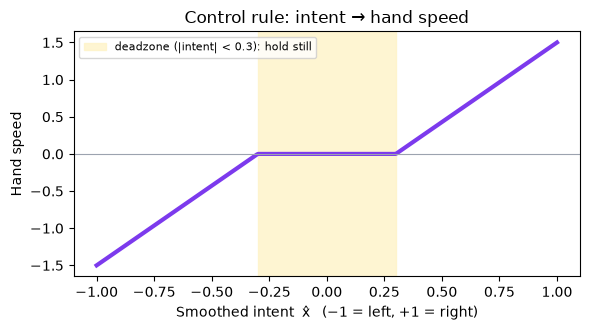

In [5]:
def deadzone(u, d):
    """0 inside the deadzone, then ramps linearly to +/-1 at |u| = 1."""
    return np.where(np.abs(u) < d, 0.0, np.sign(u) * (np.abs(u) - d) / (1 - d))

g, d = 1.5, 0.3          # max hand speed (x-units per second) and deadzone half-width

u = np.linspace(-1, 1, 400)
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(u, g * deadzone(u, d), color="#7c3aed", linewidth=3)
ax.axvspan(-d, d, color="#fef3c7", alpha=0.8, label=f"deadzone (|intent| < {d}): hold still")
ax.axhline(0, color="#9ca3af", linewidth=0.8)
ax.set_xlabel("Smoothed intent  x̂   (−1 = left, +1 = right)")
ax.set_ylabel("Hand speed")
ax.set_title("Control rule: intent → hand speed")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
def simulate_task(z, is_r, n_win, g=1.5, d=0.3, dt=0.1, first_t=2.0):
    """Run the sorting task: each trial, the hand starts at the center and integrates the intent."""
    n_trials = len(is_r)
    Z = z.reshape(n_trials, n_win)
    traj = np.zeros((n_trials, n_win + 1))               # hand x over time, per trial
    outcome = np.empty(n_trials, dtype=object)
    t_sel = np.full(n_trials, np.nan)
    for k in range(n_trials):
        h, chosen = 0.0, None
        for s in range(n_win):
            if chosen is None:
                h += g * deadzone(Z[k, s], d) * dt        # joystick: intent sets hand speed
                if abs(h) >= BIN_X:                       # reached a bin = a selection
                    h = np.sign(h) * BIN_X
                    chosen = h > 0                        # True = right bin
                    t_sel[k] = first_t + s * dt
            traj[k, s + 1] = h
        if chosen is None:
            outcome[k] = "none"
        else:
            outcome[k] = "correct" if chosen == is_r[k] else "wrong"
    return traj, outcome, t_sel

n_win = p.shape[1]
results = {}
for name, z in [("Raw decoder", z_raw), ("Kalman-filtered", z_kf)]:
    traj, outcome, t_sel = simulate_task(z, is_r, n_win, g=g, d=d, dt=dt)
    results[name] = (traj, outcome, t_sel)
    n = len(outcome)
    print(f"{name:16s} correct {np.sum(outcome == 'correct'):2d}/{n}   wrong {np.sum(outcome == 'wrong'):2d}   "
          f"no selection {np.sum(outcome == 'none'):2d}   mean time {np.nanmean(t_sel):.2f} s")

Raw decoder      correct 43/45   wrong  1   no selection  1   mean time 2.63 s
Kalman-filtered  correct 42/45   wrong  1   no selection  2   mean time 2.77 s


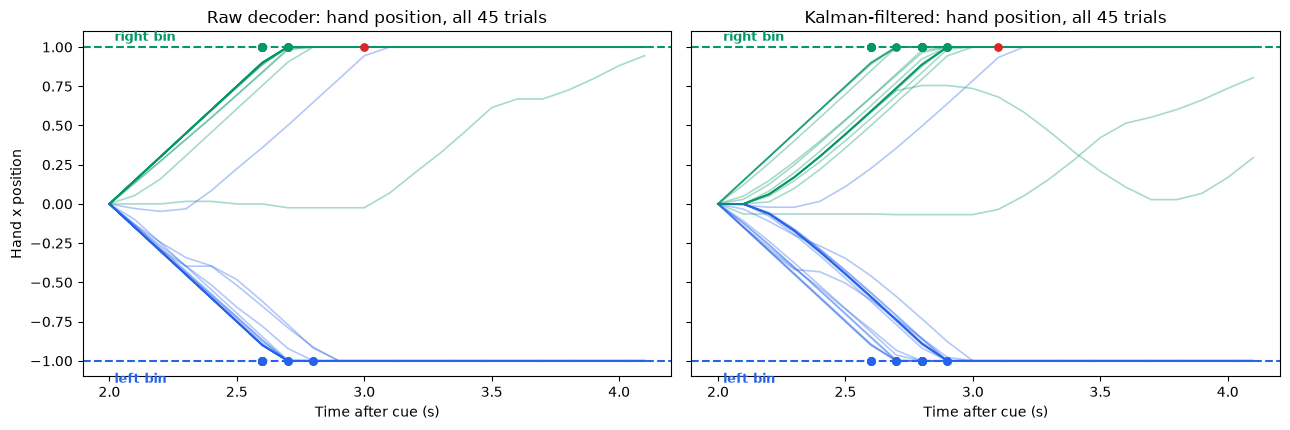

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
t_axis = 2.0 + np.arange(n_win + 1) * dt
for ax, (name, (traj, outcome, t_sel)) in zip(axes, results.items()):
    for k in range(len(is_r)):
        col = RIGHT_C if is_r[k] else LEFT_C
        ax.plot(t_axis, traj[k], color=col, alpha=0.35, linewidth=1.2)
        if not np.isnan(t_sel[k]):
            ax.scatter(t_sel[k], traj[k, -1], s=28, color=("#dc2626" if outcome[k] == "wrong" else col), zorder=3)
    ax.axhline(BIN_X, color=RIGHT_C, linestyle="--", linewidth=1.5)
    ax.axhline(-BIN_X, color=LEFT_C, linestyle="--", linewidth=1.5)
    ax.text(t_axis[0] + 0.02, BIN_X + 0.04, "right bin", color=RIGHT_C, fontsize=9, fontweight="bold")
    ax.text(t_axis[0] + 0.02, -BIN_X - 0.14, "left bin", color=LEFT_C, fontsize=9, fontweight="bold")
    ax.set_title(f"{name}: hand position, all {len(is_r)} trials")
    ax.set_xlabel("Time after cue (s)")
axes[0].set_ylabel("Hand x position")
plt.tight_layout()
plt.show()

## Step 4: Is the Smoothed Arm Actually Better?

The first run on subject 7:

| | Correct | Wrong | No selection | Mean time |
|---|---|---|---|---|
| Raw decoder | 43/45 | 1 | 1 | 2.63 s |
| Kalman-filtered | 42/45 | 1 | 2 | 2.77 s |

This is essentially a tie. The single wrong selection is the *same* trial for both arms, so it's a decoder error that no smoothing can repair. Our first "speed jerk" measure then made the Kalman arm look *twitchier* (0.156 vs 0.052). That result exposed two problems in the comparison itself:

1. **Carryover.** The filter runs continuously across trials. At the start of a left→right trial it still "points left" from the previous trial, so the commanded speed has to swing across zero before the arm moves the right way. The raw arm doesn't suffer from this, because its first window contains only the new trial's EEG. In a cued task the arm resets at every new object, so it's reasonable for the filter to reset too. We therefore compare **both versions**: *continuous* and *reset at cue*.
2. **"Jerk" can't tell a smooth ramp from a twitch.** A raw decoder that saturates at ±1 has a flat, constant speed (jerk ≈ 0), while a filter's gentle acceleration counts as "jerk" even though it's smooth. What we actually care about is **wobble**: back-and-forth movement beyond the net change. A smooth ramp has zero wobble; a glitch and its recovery have a lot.

**Metrics**

| Metric | Meaning |
|---|---|
| Correct / wrong / none | Where the object ended up |
| Time | Seconds from the cue to reaching a bin |
| ITR | Information transfer rate in bits/min. Per selection, with $N = 2$ choices and accuracy $P$: $B = 1 + P\log_2 P + (1-P)\log_2(1-P)$. Trials with no selection count as errors and use the full trial length. Rest periods between trials are ignored, so this is an upper bound. |
| Wobble | Per trial, total change in the commanded speed minus the net change. Lower means steadier. |
| Reversals | How many times the commanded direction flips before the bin is reached |

In [10]:
def bits_per_selection(P, N=2):
    """Wolpaw information transfer, bits per selection, for N equally likely choices."""
    if P <= 1 / N:
        return 0.0
    if P >= 1:
        return float(np.log2(N))
    return float(np.log2(N) + P * np.log2(P) + (1 - P) * np.log2((1 - P) / (N - 1)))

def kalman_per_trial(z, n_win, Q, R):
    """Run the filter separately on each trial: it starts fresh at every cue, like the arm does."""
    return np.concatenate([kalman_filter(row, Q, R) for row in z.reshape(-1, n_win)])

def task_metrics(z, is_r, n_win, g=1.5, d=0.3, dt=0.1, first_t=2.0):
    traj, outcome, t_sel = simulate_task(z, is_r, n_win, g=g, d=d, dt=dt, first_t=first_t)
    n = len(is_r)
    correct, wrong, none = [np.mean(outcome == o) for o in ("correct", "wrong", "none")]
    trial_time = np.where(np.isnan(t_sel), first_t + n_win * dt, t_sel)       # no selection = full trial
    itr = bits_per_selection(correct) * 60 / trial_time.mean()                 # no selection counts as an error
    S = g * deadzone(z.reshape(n, n_win), d)                                   # commanded hand speed
    last = np.where(np.isnan(t_sel), n_win - 1, np.round((np.nan_to_num(t_sel) - first_t) / dt)).astype(int)
    wobble, reversals = [], 0
    for k in range(n):
        s = S[k, :last[k] + 1]                                                 # until the bin is reached
        if len(s) > 1:
            wobble.append(np.sum(np.abs(np.diff(s))) - abs(s[-1] - s[0]))      # back-and-forth beyond the net change
        signs = np.sign(s[s != 0])
        reversals += int(np.sum(signs[1:] != signs[:-1]))
    return dict(correct=correct, wrong=wrong, none=none, time=np.nanmean(t_sel),
                itr=itr, wobble=float(np.mean(wobble)), reversals=reversals)

z_kf_reset = kalman_per_trial(z_raw, n_win, Q=0.1, R=R)
arms = [("Raw decoder", z_raw), ("Kalman (continuous)", z_kf), ("Kalman (reset at cue)", z_kf_reset)]

print(f"{'':22s} | {'correct':>7s} | {'wrong':>5s} | {'none':>5s} | {'time (s)':>8s} | {'ITR (bits/min)':>14s} | {'wobble':>6s} | {'reversals':>9s}")
for name, z in arms:
    m = task_metrics(z, is_r, n_win, g=g, d=d, dt=dt)
    print(f"{name:22s} | {m['correct']:7.1%} | {m['wrong']:5.1%} | {m['none']:5.1%} | {m['time']:8.2f} | {m['itr']:14.1f} | {m['wobble']:6.3f} | {m['reversals']:9d}")

                       | correct | wrong |  none | time (s) | ITR (bits/min) | wobble | reversals
Raw decoder            |   95.6% |  2.2% |  2.2% |     2.63 |           16.6 |  0.223 |         3
Kalman (continuous)    |   93.3% |  2.2% |  4.4% |     2.77 |           13.7 |  0.244 |         4
Kalman (reset at cue)  |   95.6% |  2.2% |  2.2% |     2.65 |           16.5 |  0.137 |         2


## Reading the Result (Subject 7)

| | Correct | Time | ITR (bits/min) | Wobble | Reversals |
|---|---|---|---|---|---|
| Raw decoder | 95.6% | 2.63 s | 16.6 | 0.223 | 3 |
| Kalman (continuous) | 93.3% | 2.77 s | 13.7 | 0.244 | 4 |
| **Kalman (reset at cue)** | **95.6%** | **2.65 s** | **16.5** | **0.137** | **2** |

- **The reset Kalman arm matches the raw arm** on selections, time and ITR, and has about **39% less wobble** in its speed commands, at a cost of 0.02 s.
- **Never resetting the filter is worse:** one extra no-selection and 0.14 s slower, because the filter has to un-learn the previous trial's intent. That is why we keep the reset version.
- **These are one-subject, 45-trial numbers.** A drop in wobble from 0.223 to 0.137 is a trend, not proof. The next step tests it on several people.

## Step 5: Does It Hold Up Across People?

We run the whole task for subjects 7, 2, 1, 3 and 5, each with the three arms. Settings stay fixed so nothing is tuned per person: the control rule ($g = 1.5$, $d = 0.3$) was chosen before seeing any results, and $Q = 0.1$ was chosen on subject 7 and carried over to the others. $R$ is calibrated per subject from that subject's own readings.

*What to expect:* for people whose decoder is at chance (subjects 3 and 5), no arm can sort correctly, since there is no signal to control it with. The interesting questions are whether smoothing helps in the middle (subjects 2 and 1), and what it costs in speed.

subj | arm                    | correct | wrong |  none | time (s) |   ITR | wobble
   7 | Raw decoder            |   95.6% |  2.2% |  2.2% |     2.63 |  16.6 |  0.223
   7 | Kalman (continuous)    |   93.3% |  2.2% |  4.4% |     2.77 |  13.7 |  0.244
   7 | Kalman (reset at cue)  |   95.6% |  2.2% |  2.2% |     2.65 |  16.5 |  0.137
   2 | Raw decoder            |   80.0% |  8.9% | 11.1% |     2.85 |   5.6 |  0.738
   2 | Kalman (continuous)    |   75.6% |  6.7% | 17.8% |     3.02 |   3.7 |  0.267
   2 | Kalman (reset at cue)  |   80.0% |  6.7% | 13.3% |     2.94 |   5.4 |  0.406
   1 | Raw decoder            |   31.1% | 20.0% | 48.9% |     3.06 |   0.0 |  1.442
   1 | Kalman (continuous)    |   28.9% |  6.7% | 64.4% |     3.21 |   0.0 |  0.704
   1 | Kalman (reset at cue)  |   28.9% |  8.9% | 62.2% |     3.09 |   0.0 |  0.644
   3 | Raw decoder            |   31.1% | 22.2% | 46.7% |     3.03 |   0.0 |  1.442
   3 | Kalman (continuous)    |   22.2% | 20.0% | 57.8% |     3.14 |   0.0 |

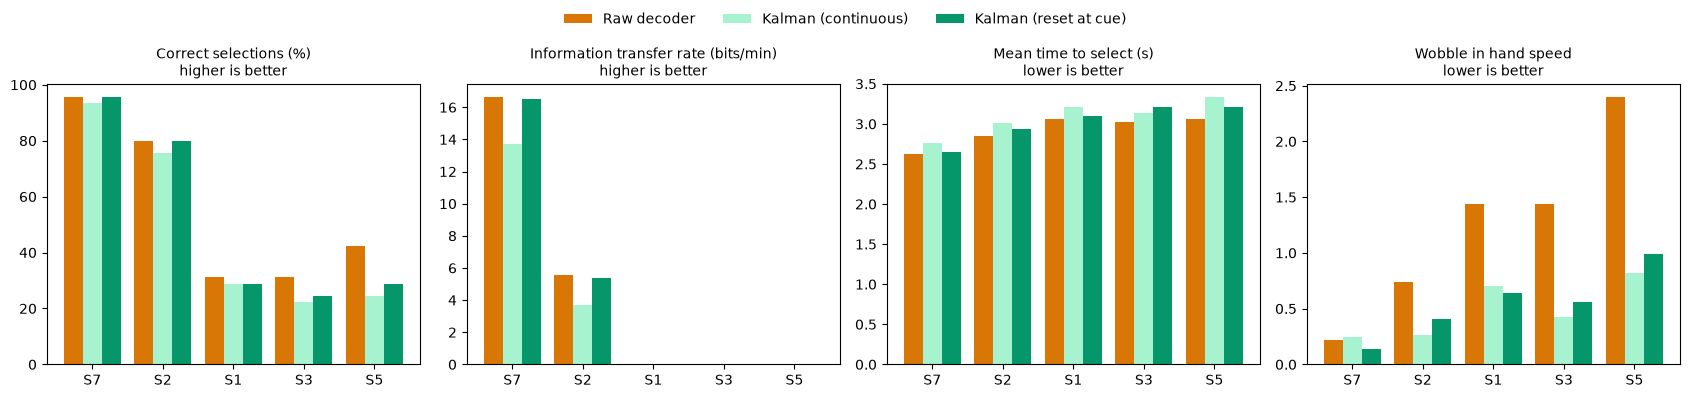

In [12]:
test_subjects = [7, 2, 1, 3, 5]
arm_names = ["Raw decoder", "Kalman (continuous)", "Kalman (reset at cue)"]
bench = {}

print(f"{'subj':>4s} | {'arm':22s} | {'correct':>7s} | {'wrong':>5s} | {'none':>5s} | {'time (s)':>8s} | {'ITR':>5s} | {'wobble':>6s}")
for s in test_subjects:
    p_s, is_r_s = decode_stream(s)
    nw = p_s.shape[1]
    z = (2 * p_s - 1).reshape(-1)
    R_s = np.var(z - np.repeat(np.where(is_r_s, 1, -1), nw))            # per-subject measurement noise
    streams = [z, kalman_filter(z, 0.1, R_s), kalman_per_trial(z, nw, 0.1, R_s)]
    bench[s] = [task_metrics(zz, is_r_s, nw, g=g, d=d, dt=dt) for zz in streams]
    for name, m in zip(arm_names, bench[s]):
        print(f"{s:4d} | {name:22s} | {m['correct']:7.1%} | {m['wrong']:5.1%} | {m['none']:5.1%} | {m['time']:8.2f} | {m['itr']:5.1f} | {m['wobble']:6.3f}")

print("\nMean across subjects")
for i, name in enumerate(arm_names):
    ms = [bench[s][i] for s in test_subjects]
    print(f"{name:22s} | correct {np.mean([m['correct'] for m in ms]):6.1%} | time {np.mean([m['time'] for m in ms]):.2f} s | "
          f"ITR {np.mean([m['itr'] for m in ms]):5.1f} | wobble {np.mean([m['wobble'] for m in ms]):.3f}")

fig, axes = plt.subplots(1, 4, figsize=(17, 4))
panels = [("correct", "Correct selections (%)\nhigher is better", 100),
          ("itr", "Information transfer rate (bits/min)\nhigher is better", 1),
          ("time", "Mean time to select (s)\nlower is better", 1),
          ("wobble", "Wobble in hand speed\nlower is better", 1)]
colors = ["#d97706", "#a7f3d0", "#059669"]
x = np.arange(len(test_subjects))
for ax, (key, title, mult) in zip(axes, panels):
    for i, (name, col) in enumerate(zip(arm_names, colors)):
        ax.bar(x + (i - 1) * 0.27, [np.nan_to_num(bench[s][i][key]) * mult for s in test_subjects], 0.27, color=col, label=name)
    ax.set_xticks(x)
    ax.set_xticklabels([f"S{s}" for s in test_subjects])
    ax.set_title(title, fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=10, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.savefig("../images/arm_subject_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading the Result (Five Subjects)

| Arm | Correct | Wrong | No selection | Time to select | ITR (bits/min) | Wobble |
|---|---|---|---|---|---|---|
| Raw decoder | 56.0% | 18.2% | 25.8% | 2.93 s | 4.4 | 1.248 |
| Kalman (never reset) | 48.9% | 12.9% | 38.2% | 3.09 s | 3.5 | 0.492 |
| **Kalman (reset at cue)** | 51.6% | 12.4% | 36.0% | 3.02 s | 4.4 | 0.548 |

**What the filter buys us**
- **A much steadier arm.** Wobble drops by about 56% on average, and for every subject.
- **Fewer wrong selections** (18.2% → 12.4%). The filter and deadzone make the arm hold still when the evidence is shaky instead of committing to a guess.
- **The same ITR as the raw decoder** (4.4 bits/min) once the filter is reset at each cue. Never resetting is worse, which confirms the carryover cost from Step 4.

**What it costs**
- Fewer correct selections (56.0% → 51.6%). Most of the "lost" ones became "no selection", not wrong selections.
- About 0.1 s slower per selection.
- It is a trade, not a free win. For a real device, a wrong action is usually worse than a pause, which is why we keep the reset-at-cue Kalman arm as the main smoothed controller.

**What it cannot fix**
- Subjects 1, 3 and 5 cannot really sort objects with any arm (ITR ≈ 0). Their decoders are near chance, and smoothing noise cannot create information that isn't there.
- Task-level numbers are lower than window-level decoder accuracy. For example, subject 1 is about 62% per window but only 31% correct sorts, because the hand needs roughly a second of *sustained* evidence to reach a bin.

**Limitations**
- Everything is a simulation, replayed offline from recorded EEG. No live closed loop.
- R is calibrated using the true labels, and Q was tuned on subject 7 only.
- ITR ignores rest periods between trials, so it is an upper bound.

## Step 6: Animate It

Numbers are hard to feel, so here is the same task as a short movie. The first 8 trials of one subject are shown **in order, not hand-picked**. Both arms receive the same brain signal. Left is the raw decoder, right is the Kalman-filtered arm (reset at each cue).

Under each arm is a live trace of the hand position. Watch how much smoother the Kalman trace is. Green object = correct bin, red = wrong bin, grey = no selection.

raw   : ['correct', 'correct', 'correct', 'correct', 'correct', 'correct', 'correct', 'correct']
kalman: ['correct', 'correct', 'correct', 'correct', 'correct', 'correct', 'correct', 'correct']


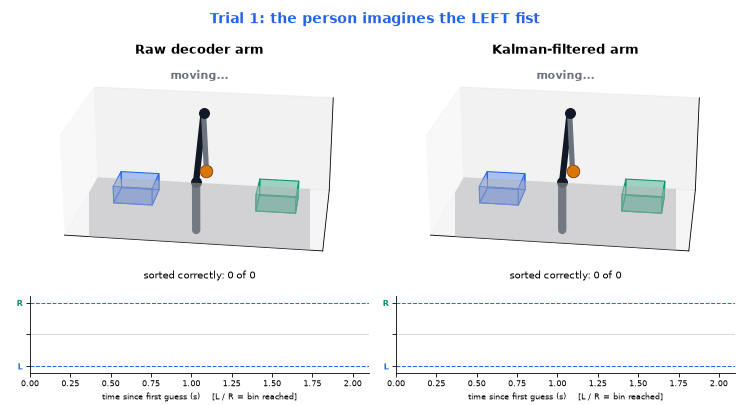

In [13]:
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from IPython.display import Image, display

demo_subject = 2        # change this to animate a different subject
n_show = 8              # how many trials to show (the first n_show, in order)

p_d, is_r_d = decode_stream(demo_subject)
n_win_d = p_d.shape[1]
z_d = (2 * p_d - 1).reshape(-1)
R_d = np.var(z_d - np.repeat(np.where(is_r_d, 1, -1), n_win_d))
z_d_kf = np.concatenate([kalman_filter(row, Q=0.1, R=R_d) for row in z_d.reshape(-1, n_win_d)])  # reset at every cue

arms = [("Raw decoder arm",      *simulate_task(z_d,    is_r_d, n_win_d, g=1.5, d=0.3)[:2], "#7c3aed"),
        ("Kalman-filtered arm",  *simulate_task(z_d_kf, is_r_d, n_win_d, g=1.5, d=0.3)[:2], "#0f766e")]

def end_step(traj_k):
    hit = np.abs(traj_k) >= BIN_X - 1e-9
    return int(np.argmax(hit)) if hit.any() else n_win_d

frames = []
for k in range(n_show):
    last = max(end_step(a[1][k]) for a in arms)
    frames += [(k, s) for s in range(last + 1)] + [(k, last)] * 4      # hold the result for a moment

fig = plt.figure(figsize=(10, 5.4))
gs = GridSpec(2, 2, height_ratios=[3.2, 1.1], left=0.04, right=0.98, top=0.86, bottom=0.08, hspace=0.12, wspace=0.08)
ax3 = [fig.add_subplot(gs[0, j], projection="3d") for j in range(2)]
axt = [fig.add_subplot(gs[1, j]) for j in range(2)]

def update(i):
    k, s = frames[i]
    for j, (name, traj, outcome, line_col) in enumerate(arms):
        ax, at = ax3[j], axt[j]
        ax.cla(); at.cla()
        setup_scene(ax); ax.set_xlabel(""); ax.set_box_aspect((3.4, 2.0, 1.4), zoom=1.35)
        done = end_step(traj[k]) <= s
        status, col = "moving...", "#6b7280"
        if done:
            status, col = {"correct": ("sorted correctly", RIGHT_C), "wrong": ("WRONG bin", "#dc2626"),
                           "none": ("no selection", "#6b7280")}[outcome[k]]
        draw_arm(ax, traj[k, min(s, n_win_d)], object_color=col if done and outcome[k] != "none" else "#d97706")
        tally = int(np.sum(outcome[:k] == "correct")) + int(done and outcome[k] == "correct")
        ax.set_title(name, fontsize=12, fontweight="bold", pad=0)
        ax.text2D(0.5, 0.9, status, transform=ax.transAxes, ha="center", fontsize=11, fontweight="bold", color=col)
        ax.text2D(0.5, 0.0, f"sorted correctly: {tally} of {k + (1 if done else 0)}", transform=ax.transAxes, ha="center", fontsize=10)
        # live trace of the hand position
        t = np.arange(s + 1) * dt
        at.axhline(1, color=RIGHT_C, ls="--", lw=1); at.axhline(-1, color=LEFT_C, ls="--", lw=1)
        at.axhline(0, color="#d1d5db", lw=0.8)
        at.plot(t, traj[k, :s + 1], color=line_col, lw=2)
        at.set_xlim(0, n_win_d * dt); at.set_ylim(-1.2, 1.2)
        at.set_yticks([-1, 0, 1]); at.set_yticklabels(["L", "", "R"], fontsize=9, fontweight="bold")
        at.get_yticklabels()[0].set_color(LEFT_C); at.get_yticklabels()[2].set_color(RIGHT_C)
        at.set_xlabel("time since first guess (s)    [L / R = bin reached]", fontsize=8)
        at.tick_params(labelsize=8)
        for sp in ("top", "right"): at.spines[sp].set_visible(False)
    fig.suptitle(f"Trial {k + 1}: the person imagines the {'RIGHT' if is_r_d[k] else 'LEFT'} fist",
                 fontsize=13, fontweight="bold", color=RIGHT_C if is_r_d[k] else LEFT_C, y=0.97)

ani = FuncAnimation(fig, update, frames=len(frames), interval=100)
ani.save("../images/sorting_demo.gif", writer=PillowWriter(fps=10), dpi=75)
plt.close(fig)

print("raw   :", list(arms[0][2][:n_show]))
print("kalman:", list(arms[1][2][:n_show]))
display(Image(filename="../images/sorting_demo.gif"))

### Phase 4: Brain-Controlled Sorting Task ✅

The smoothed intent signal drives a simulated 3-joint robotic arm that **sorts objects into a left or right bin**. The person imagines a left or right fist, and the hand slides toward the matching bin like a joystick: decoded intent sets the hand's *speed*, and a small deadzone means weak evidence does nothing. When the hand reaches a bin, that is the selection.

![Brain-controlled sorting demo](images/sorting_demo.gif)

*Same brain signal, two arms: raw decoder (left) vs. Kalman-filtered (right). First 8 trials of subject 2, shown in order, not hand-picked.*

**How it works**
- **Control:** hand velocity = g · deadzone(x̂), with gain g = 1.5 and deadzone d = 0.3, both fixed in advance rather than tuned on results. The hand and the filter reset at every cue.
- **Inverse kinematics:** for a hand target, the base yaw, shoulder and elbow angles are solved in closed form (law of cosines, elbow-up), so the arm follows the hand smoothly.

  ![Inverse kinematics geometry](images/ik_geometry.png)
- **Task metrics:** correct / wrong / no selection, time to select, information transfer rate (Wolpaw ITR), and *wobble*, which measures how much the commanded speed jitters beyond its net change.

**Results: five subjects, 45 trials each (decoded out-of-fold)**

| Arm | Correct | Wrong | No selection | Time to select | ITR (bits/min) | Wobble |
|---|---|---|---|---|---|---|
| Raw decoder | 56.0% | 18.2% | 25.8% | 2.93 s | 4.4 | 1.248 |
| Kalman (never reset) | 48.9% | 12.9% | 38.2% | 3.09 s | 3.5 | 0.492 |
| **Kalman (reset at cue)** | 51.6% | 12.4% | 36.0% | 3.02 s | 4.4 | 0.548 |

| Subject | Correct (raw) | Correct (Kalman) | Wobble (raw) | Wobble (Kalman) |
|---|---|---|---|---|
| 7 | 95.6% | 95.6% | 0.223 | 0.137 |
| 2 | 80.0% | 80.0% | 0.738 | 0.406 |
| 1 | 31.1% | 28.9% | 1.442 | 0.644 |
| 3 | 31.1% | 24.4% | 1.442 | 0.559 |
| 5 | 42.2% | 28.9% | 2.397 | 0.993 |

![Subject benchmark](images/arm_subject_benchmark.png)

**Takeaways**
- The Kalman filter makes the arm about **56% steadier** and cuts wrong selections from 18.2% to 12.4%. The arm holds still when the evidence is shaky instead of committing.
- The price is fewer correct selections (56.0% → 51.6%) and about 0.1 s more time per selection. With reset at each cue, ITR matches the raw decoder.
- The arm works well for subjects with a decodable signal (subjects 7 and 2) and **not at all for subjects 1, 3 and 5**, whose decoders are near chance. Smoothing cannot create information that isn't in the signal.

**Limitations**
- Everything is simulated and replayed offline from recorded EEG. There is no live closed loop and no physical arm.
- The Kalman noise term R is calibrated using the true labels, and the process noise Q was tuned on subject 7 only.
- ITR ignores the rest periods between trials, so it is an upper bound.